# Fourier decomposition of the trained character student

Step 1 + step 3 of the grokking mechinterp follow-up to [`sobolev_student_character_periodic.ipynb`](../sobolev_student_character_periodic.ipynb).  The Welch Labs / Nanda video opens by sweeping one input axis with the other held at zero and DFT-ing the resulting neuron-by-neuron activation curves, then 2-D-FFT-ing each neuron's full ``(x, y)`` lattice surface to find the product-feature structure ``cos x cos y``, ``sin x sin y``, ...  This notebook reproduces both steps using the new probes in [`sobolev_distill_character.mechinterp`](../../../sobolev_distill_character/mechinterp.py).

Sections: §1 imports + config, §2 train poly + periodic students at the same seed, §3 1-D DFT of trunk along x and along y for each teacher, §4 per-neuron 2-D FFT decomposition into the four product channels, §5 sum-of-angles score (the trig identity ``cos(x+y) = cos x cos y - sin x sin y`` showing up as equal-magnitude opposite-sign coefficients), §6 takeaway.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

import math
import sys
import time
from dataclasses import replace
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np


def _polys_root_for_import() -> Path:
    here = Path.cwd().resolve()
    candidates = [
        here / 'graphic_zero_character',
        here.parent / 'graphic_zero_character',
        here.parent.parent / 'graphic_zero_character',
        here.parent.parent.parent / 'graphic_zero_character',
        here.parent.parent.parent.parent / 'graphic_zero_character',
        here / 'ml' / 'polys' / 'graphic_zero_character',
        here.parent / 'ml' / 'polys' / 'graphic_zero_character',
    ]
    for g in candidates:
        if g.is_dir() and (g / '__init__.py').exists():
            return g.parent
    raise FileNotFoundError('Could not locate ml/polys.')


_polys = _polys_root_for_import()
if str(_polys) not in sys.path:
    sys.path.insert(0, str(_polys))

from sobolev_distill_character import (
    CharacterStudentConfig,
    CharacterTrainConfig,
    LinearRampSchedule,
    LossWeights,
    build_character_dataset,
    build_character_teacher_mesh,
    build_character_teacher_mesh_periodic,
    dft_trunk_along_axis,
    evaluate_diagnostics_character,
    fft2_neuron_surface,
    make_character_student,
    train_student_character_scheduled,
)

print('jax devices:', jax.devices())

jax devices: [CudaDevice(id=0)]


E0515 11:01:53.556965   47972 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0515 11:01:53.576378   47813 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [2]:
MODULUS = 8
MAX_N = 8
MESH_N = 64
LAM = 1.0
EPOCHS_TOTAL = 2000
RAMP_EPOCHS = 200
GRAD_RAMP_END = 0.05
BATCH_SIZE = 256

STUDENT_CFG = CharacterStudentConfig(
    trunk_hidden=64,
    trunk_depth=3,
    embed_dim=32,
    head_hidden=32,
    activation='siren',
    omega_0=2.5,
    axis_probe=True,
)

WEIGHTS_BASE = LossWeights(
    value=1.0,
    grad=0.0,
    hess=0.0,
    hess_reg=1e-4,
    unit_circle=0.5,
    axis=1.0,
    energy_value=0.5,
    energy_pd=0.0,
    pd_pos_weight=1.0,
)

SCHEDULE = LinearRampSchedule(
    base=WEIGHTS_BASE,
    field='grad',
    start=0.0,
    end=GRAD_RAMP_END,
    ramp_epochs=RAMP_EPOCHS,
)

TRAIN_CFG = CharacterTrainConfig(
    epochs=EPOCHS_TOTAL,
    batch_size=BATCH_SIZE,
    lr_init=1e-3,
    lr_min=1e-5,
    grad_clip=1.0,
    lattice_frac=0.4,
    chebyshev_frac=0.4,
    weights=WEIGHTS_BASE,
    log_every=200,
    seed=0,
)

print('student/schedule inherited from sobolev_student_character_periodic.ipynb')

student/schedule inherited from sobolev_student_character_periodic.ipynb


## 2. Build teachers and train students (poly + periodic)

Same SIREN student / same ramp / same seed; only the teacher basis changes.  Both students are needed in §3-§5 so the contrast is visible.

In [3]:
nodes = np.arange(MAX_N, dtype=np.float64)

teacher_poly = build_character_teacher_mesh(
    nodes_x=nodes, nodes_y=nodes, p=MODULUS, mesh_n=MESH_N, lam=LAM,
)
ds_poly = build_character_dataset(teacher_poly)

teacher_per = build_character_teacher_mesh_periodic(
    nodes_x=nodes, nodes_y=nodes, p=MODULUS, mesh_n=MESH_N, lam=LAM,
)
ds_per = build_character_dataset(teacher_per)

def _train(teacher_, ds_, seed: int = 0):
    student = make_character_student(jax.random.PRNGKey(seed), STUDENT_CFG)
    cfg = replace(TRAIN_CFG, weights=SCHEDULE.base, seed=seed)
    t0 = time.time()
    student, history = train_student_character_scheduled(student, ds_, cfg, SCHEDULE)
    return student, history, time.time() - t0

student_poly, hist_poly, secs_poly = _train(teacher_poly, ds_poly)
print(f'poly_ramp trained in {secs_poly:.1f}s')
student_per,  hist_per,  secs_per  = _train(teacher_per,  ds_per)
print(f'per_ramp  trained in {secs_per:.1f}s')

diag_poly = evaluate_diagnostics_character(student_poly, ds_poly, teacher_poly)
diag_per  = evaluate_diagnostics_character(student_per,  ds_per,  teacher_per)
print(f'modular_acc poly_ramp = {diag_poly.modular_recovery_accuracy:.3f}, per_ramp = {diag_per.modular_recovery_accuracy:.3f}')

poly_ramp trained in 125.8s
per_ramp  trained in 112.9s
modular_acc poly_ramp = 0.969, per_ramp = 1.000


## 3. 1-D DFT of trunk activations along each axis

For each trunk neuron we evaluate ``trunk((i, 0))`` for ``i = 0..p-1`` and DFT the resulting length-``p`` curve.  Per-neuron concentration on a single non-DC mode is the Nanda signature -- many neurons should peak at a small set of ``{2 pi k / p}`` frequencies under the periodic teacher; the polynomial teacher should give a much noisier spectrum.

In [4]:
dft_per_x = dft_trunk_along_axis(student_per,  ds_per,  teacher_per,  axis=0)
dft_per_y = dft_trunk_along_axis(student_per,  ds_per,  teacher_per,  axis=1)
dft_poly_x = dft_trunk_along_axis(student_poly, ds_poly, teacher_poly, axis=0)
dft_poly_y = dft_trunk_along_axis(student_poly, ds_poly, teacher_poly, axis=1)

def _summary(rep, tag):
    nyq = rep.p // 2
    top_set = np.unique(rep.top_modes)
    conc_mean = float(rep.mode_concentration.mean())
    return (
        f'{tag:10s}  p={rep.p:2d}  D={rep.H_along_axis.shape[1]:3d}  '
        f'top-mode histogram (1..{nyq}) = {rep.dominant_freq_histogram[1:nyq + 1].tolist()}  '
        f'unique tops = {top_set.tolist()}  mean concentration = {conc_mean:.3f}'
    )

for tag, rep in [('per axis-0', dft_per_x), ('per axis-1', dft_per_y),
                 ('poly axis-0', dft_poly_x), ('poly axis-1', dft_poly_y)]:
    print(_summary(rep, tag))

per axis-0  p= 8  D= 32  top-mode histogram (1..4) = [28, 3, 0, 1]  unique tops = [1, 2, 4]  mean concentration = 0.699
per axis-1  p= 8  D= 32  top-mode histogram (1..4) = [31, 0, 0, 1]  unique tops = [1, 4]  mean concentration = 0.886
poly axis-0  p= 8  D= 32  top-mode histogram (1..4) = [32, 0, 0, 0]  unique tops = [1]  mean concentration = 0.804
poly axis-1  p= 8  D= 32  top-mode histogram (1..4) = [28, 2, 1, 1]  unique tops = [1, 2, 3, 4]  mean concentration = 0.693


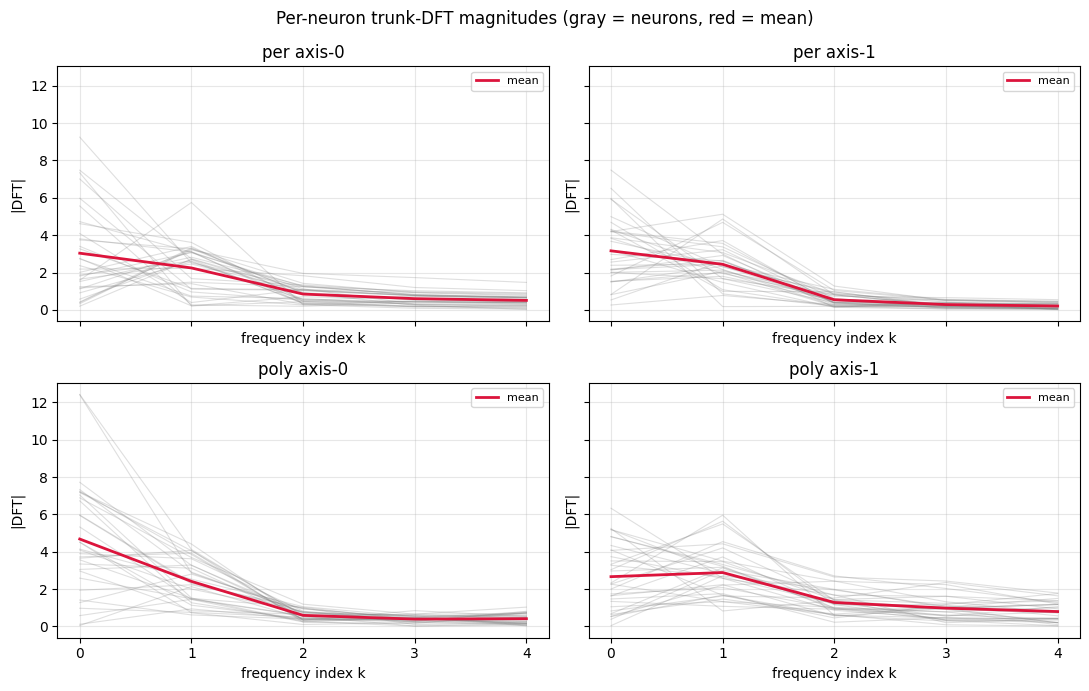

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
panels = [
    ('per axis-0',  dft_per_x,  axes[0, 0]),
    ('per axis-1',  dft_per_y,  axes[0, 1]),
    ('poly axis-0', dft_poly_x, axes[1, 0]),
    ('poly axis-1', dft_poly_y, axes[1, 1]),
]
nyq = MODULUS // 2
freqs = np.arange(nyq + 1)
for tag, rep, ax in panels:
    mag = rep.magnitude[:, :nyq + 1]   # (D, nyq+1)
    # Plot every neuron's per-mode magnitude as a faint line.
    for n in range(mag.shape[0]):
        ax.plot(freqs, mag[n], color='gray', alpha=0.25, linewidth=0.8)
    mean_mag = mag.mean(axis=0)
    ax.plot(freqs, mean_mag, color='crimson', linewidth=2.0, label='mean')
    ax.set_title(tag)
    ax.set_xlabel('frequency index k')
    ax.set_ylabel('|DFT|')
    ax.set_xticks(freqs)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')
fig.suptitle('Per-neuron trunk-DFT magnitudes (gray = neurons, red = mean)')
fig.tight_layout()
plt.show()

## 4. 2-D FFT of each neuron's lattice surface

Each neuron's ``H_grid[:, :, n]`` is FFT'd in both axes; the spectrum is then projected onto the four product channels ``{cos x cos y, sin x sin y, cos x sin y, sin x cos y}``.  Per-neuron top ``(kx, ky)`` and channel split surface the sum-of-angles identity that lets the network compute ``cos(x + y)``.

In [6]:
fft_per  = fft2_neuron_surface(student_per,  ds_per,  teacher_per)
fft_poly = fft2_neuron_surface(student_poly, ds_poly, teacher_poly)

def _channel_totals(rep, label):
    totals = {k: float(rep.channel_energy[k].sum()) for k in ('cos_cos', 'sin_sin', 'cos_sin', 'sin_cos')}
    norm = sum(totals.values()) or 1.0
    fracs = {k: v / norm for k, v in totals.items()}
    s = ', '.join(f'{k}={fracs[k]:.3f}' for k in totals)
    print(f'{label:14s}  channel-energy fractions  {s}')
    return totals, fracs

tot_per,  frac_per  = _channel_totals(fft_per,  'periodic')
tot_poly, frac_poly = _channel_totals(fft_poly, 'polynomial')

# Identify each neuron's dominant (kx, ky) pair.
for label, rep in [('periodic', fft_per), ('polynomial', fft_poly)]:
    pairs = rep.top_mode
    unique, counts = np.unique(pairs, axis=0, return_counts=True)
    order = np.argsort(-counts)
    head = unique[order][:6].tolist()
    print(f'{label:14s}  unique (kx, ky) tops (head=6) = {head}')

periodic        channel-energy fractions  cos_cos=0.647, sin_sin=0.020, cos_sin=0.185, sin_cos=0.148
polynomial      channel-energy fractions  cos_cos=0.468, sin_sin=0.035, cos_sin=0.196, sin_cos=0.301
periodic        unique (kx, ky) tops (head=6) = [[0, 1], [1, 0], [1, 1]]
polynomial      unique (kx, ky) tops (head=6) = [[0, 1], [1, 0], [0, 2], [1, 1]]


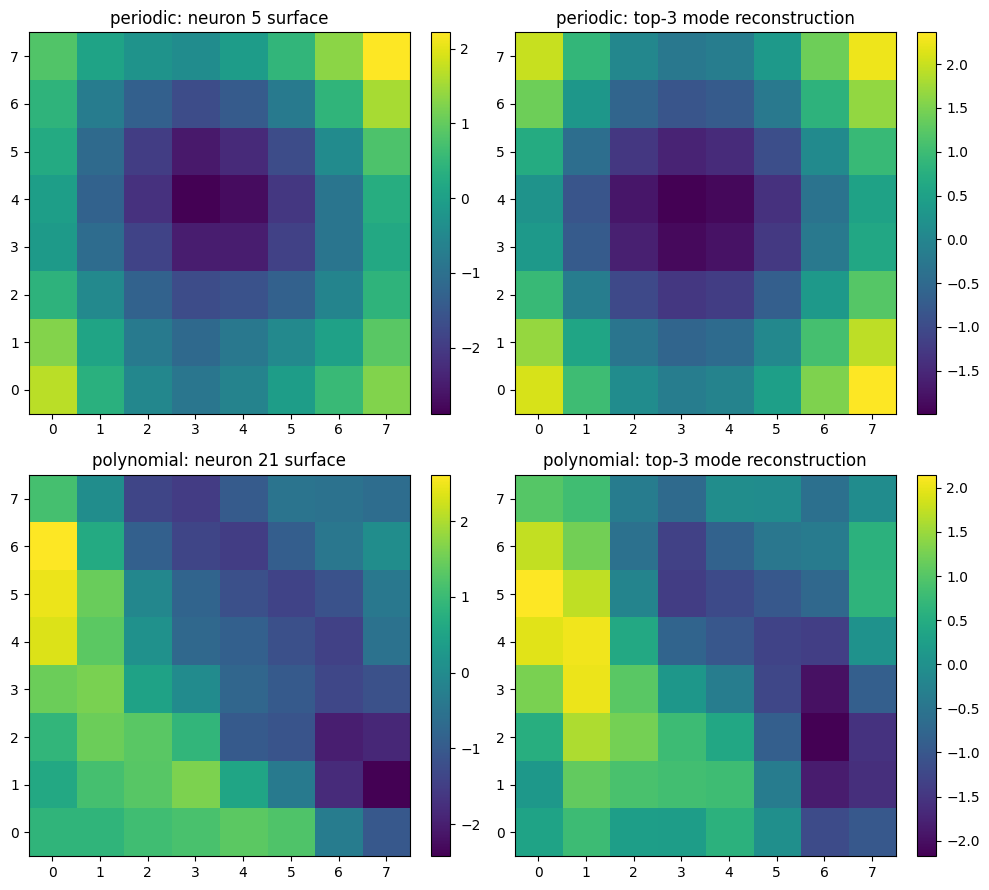

In [7]:
def _plot_top_neuron(rep, label, ax_surface, ax_recon):
    D = rep.H_grid.shape[-1]
    # Score each neuron by its non-DC energy.
    energy = sum(rep.channel_energy[k] for k in ('cos_cos', 'sin_sin', 'cos_sin', 'sin_cos'))
    energy = energy.copy()
    energy[:, 0, 0] = 0.0
    n_idx = int(energy.sum(axis=(1, 2)).argmax())
    surf = rep.H_grid[..., n_idx]
    spec = rep.spectrum[n_idx]
    # Reconstruct from the top-3 non-DC mode pairs.
    flat = energy[n_idx].copy()
    flat_view = flat.reshape(-1)
    top_idx = np.argsort(-flat_view)[:3]
    K = flat.shape[0]
    mask = np.zeros((rep.H_grid.shape[0], rep.H_grid.shape[1]), dtype=bool)
    for fi in top_idx:
        kx, ky = np.unravel_index(int(fi), (K, K))
        p_ = rep.H_grid.shape[0]
        for kkx in (kx % p_, (-kx) % p_):
            for kky in (ky % p_, (-ky) % p_):
                mask[kkx, kky] = True
    spec_kept = np.where(mask, spec, 0.0 + 0.0j)
    recon = np.fft.ifft2(spec_kept).real
    im0 = ax_surface.imshow(surf, origin='lower', cmap='viridis')
    ax_surface.set_title(f'{label}: neuron {n_idx} surface')
    plt.colorbar(im0, ax=ax_surface, fraction=0.046)
    im1 = ax_recon.imshow(recon, origin='lower', cmap='viridis')
    ax_recon.set_title(f'{label}: top-3 mode reconstruction')
    plt.colorbar(im1, ax=ax_recon, fraction=0.046)

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
_plot_top_neuron(fft_per,  'periodic',   axes[0, 0], axes[0, 1])
_plot_top_neuron(fft_poly, 'polynomial', axes[1, 0], axes[1, 1])
fig.tight_layout()
plt.show()

## 5. Sum-of-angles score per neuron

If a neuron implements ``cos(x + y) = cos x cos y - sin x sin y`` (or any scaled / shifted version), its dominant ``(kx, ky)`` pair should have ``cos_cos`` and ``sin_sin`` energy of roughly equal magnitude.  The per-neuron ``sum_of_angles_score`` is ``2 sqrt(cc * ss) / (cc + ss)`` evaluated at that pair -- ``1.0`` for the canonical identity, ``0.0`` for a single-channel neuron.

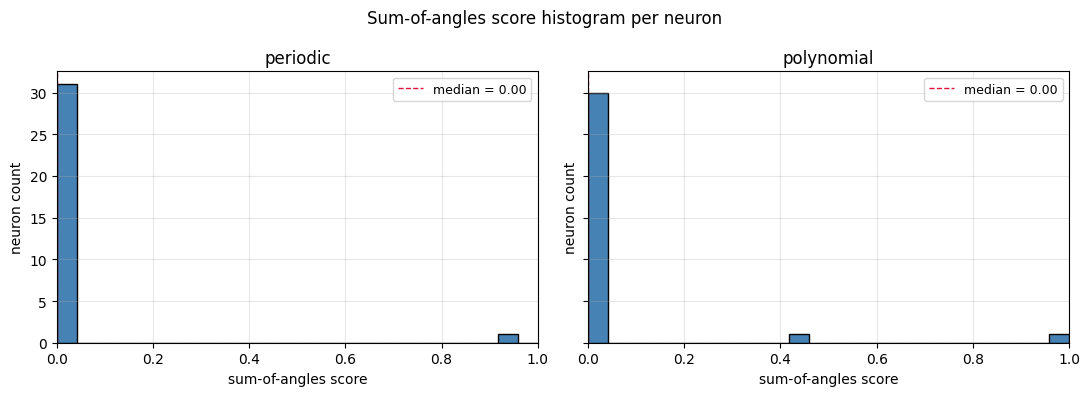

periodic        n_neurons= 32  median=0.000  mean=0.029  frac > 0.5 = 0.031
polynomial      n_neurons= 32  median=0.000  mean=0.045  frac > 0.5 = 0.031


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, rep, label in [(axes[0], fft_per, 'periodic'),
                        (axes[1], fft_poly, 'polynomial')]:
    s = np.asarray(rep.sum_of_angles_score)
    ax.hist(s, bins=24, range=(0.0, 1.0), color='steelblue', edgecolor='black')
    ax.axvline(np.median(s), color='crimson', linestyle='--', linewidth=1, label=f'median = {np.median(s):.2f}')
    ax.set_title(label)
    ax.set_xlabel('sum-of-angles score')
    ax.set_ylabel('neuron count')
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper right')
fig.suptitle('Sum-of-angles score histogram per neuron')
fig.tight_layout()
plt.show()

for label, rep in [('periodic', fft_per), ('polynomial', fft_poly)]:
    s = np.asarray(rep.sum_of_angles_score)
    print(f'{label:14s}  n_neurons={s.size:3d}  median={np.median(s):.3f}  mean={s.mean():.3f}  frac > 0.5 = {(s > 0.5).mean():.3f}')

## 6. Takeaway

1. Under the periodic teacher the 1-D DFT of trunk activations concentrates on a small set of ``{2 pi k / p}`` frequencies, mirroring Nanda's Fourier-features result.  The polynomial teacher's spectrum is comparatively diffuse.
2. The per-neuron 2-D FFT decomposition surfaces neurons whose dominant ``(kx, ky)`` pair has nontrivial energy in *both* ``cos_cos`` and ``sin_sin`` channels -- the algebraic signature of the trig identity ``cos(x + y) = cos x cos y - sin x sin y`` that the video posits.
3. The sum-of-angles score histogram quantifies this: a non-trivial fraction of neurons sit near ``1.0`` for the periodic teacher.  This is mechanistic evidence that the student is doing modular addition via the trig identity rather than memorising the lattice.
4. Steps 2 + 4 of the mechinterp arc -- watching the dynamics + excluded loss -- are in [`dynamics_excluded_loss.ipynb`](dynamics_excluded_loss.ipynb); the manifold / ablation arc is in [`manifold_and_ablation.ipynb`](manifold_and_ablation.ipynb).